In [1]:
#!pip install tensorflow
#!pip install pillow
#!pip install scipy
#!pip install opencv-python
#!pip install matplotlib

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import json
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
# Configuration
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
NUM_CLASSES = 9
EPOCHS_INITIAL = 10
EPOCHS_FINE_TUNE = 10
DATA_DIR = 'Mushrooms'

In [4]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 5375 images belonging to 9 classes.


In [6]:
val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1339 images belonging to 9 classes.


In [7]:
# Save class indices for testing
with open('class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

In [8]:
# Load base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initial layers for feature extraction

In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), 
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [10]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mobilenet_v2.keras', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
]

In [12]:
model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS_INITIAL, callbacks=callbacks)

C:\Users\keert\anaconda3\envs\MLProject2\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3588 - loss: 2.0212  

C:\Users\keert\anaconda3\envs\MLProject2\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.56983, saving model to mobilenet_v2.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.3594 - loss: 2.0192 - val_accuracy: 0.5698 - val_loss: 1.1882 - learning_rate: 0.0010
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5534 - loss: 1.2973  
Epoch 2: val_accuracy improved from 0.56983 to 0.57954, saving model to mobilenet_v2.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.5535 - loss: 1.2970 - val_accuracy: 0.5795 - val_loss: 1.2385 - learning_rate: 0.0010
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5927 - loss: 1.1711  
Epoch 3: val_accuracy improved from 0.57954 to 0.61613, saving model to mobilenet_v2.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.5928 - loss: 1.1709 - val_accuracy: 0.6161 - val_loss: 1.1505 - learning_rate: 0.0010
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6367 - loss: 1.0377  
Epoch 4: val_accuracy improved from 0.6161

In [13]:
# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [14]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
# Continue training with fine-tuning
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS_FINE_TUNE, callbacks=callbacks)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5531 - loss: 1.3358   
Epoch 1: val_accuracy did not improve from 0.65646
168/168 ━━━━━━━━━━━━━━━━━━━━ 793s 4s/step - accuracy: 0.5532 - loss: 1.3355 - val_accuracy: 0.6490 - val_loss: 1.1474 - learning_rate: 1.0000e-05
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6092 - loss: 1.1421   
Epoch 2: val_accuracy did not improve from 0.65646
168/168 ━━━━━━━━━━━━━━━━━━━━ 723s 4s/step - accuracy: 0.6093 - loss: 1.1419 - val_accuracy: 0.6535 - val_loss: 1.1799 - learning_rate: 1.0000e-05
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6517 - loss: 1.0528  
Epoch 3: val_accuracy did not improve from 0.65646
168/168 ━━━━━━━━━━━━━━━━━━━━ 752s 4s/step - accuracy: 0.6517 - loss: 1.0526 - val_accuracy: 0.6460 - val_loss: 1.1199 - learning_rate: 1.0000e-05
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6665 - loss: 0.9764  
Epoch 4: val_accuracy improved from 0.65646 to 0.66318, sav

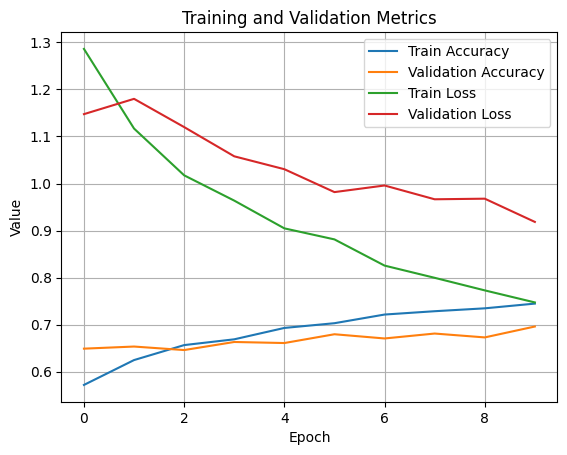

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training and Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [17]:
# Save final model
model.save('mobilenet_v2_final.keras')